<a href="https://colab.research.google.com/github/elisaehi/Brain-Tumor-Diagnostic-Tool/blob/main/PersonalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pickle



In [ ]:
train_images_path = '/content/drive/MyDrive/AI + Medicine/projects/BraTS 2018/train/images'
train_masks_path = '/content/drive/MyDrive/AI + Medicine/projects/BraTS 2018/train/masks'
val_images_path = '/content/drive/MyDrive/AI + Medicine/projects/BraTS 2018/val/images'
val_masks_path = '/content/drive/MyDrive/AI + Medicine/projects/BraTS 2018/val/masks'
# the pathway to the file in google drive

train_images_list = os.listdir(train_images_path)
train_images_list.sort()
train_masks_list = os.listdir(train_masks_path)
train_masks_list.sort()
# sorts the images so that they are aligned

val_images_list = os.listdir(val_images_path)
val_images_list.sort()
val_masks_list = os.listdir(val_masks_path)
val_masks_list.sort()
# sorts the images so that they are aligned





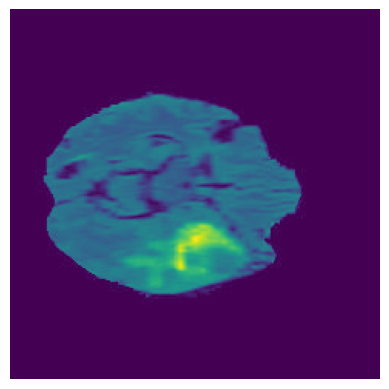

In [ ]:

image_filename = "BRATS_001_60.jpg"
image_path = os.path.join(train_images_path, image_filename)
img = Image.open(image_path)
# the pathway to the image

plt.imshow(img)
plt.axis("off")  # Hide axis labels
plt.show()
# display the image


In [ ]:
import tensorflow as tf
#machine learning and aritifical intelligence library

In [ ]:
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.set_visible_devices(physical_devices[0], 'GPU')
    #helps to run the GPU better maximing efficeny and time.

In [ ]:
target_w = 320
target_h = 320
channels = 1
n_samples = len(train_images_list)
images = np.zeros((n_samples, target_h, target_w, channels))

target_w = 320
target_h = 320
channels = 1
n_samples = len(train_masks_list)
masks = np.zeros((n_samples, target_h, target_w, channels))



In [ ]:
np.unique(masks, return_counts=True)

(array([0.]), array([384614400]))

In [ ]:
np.save("/content/drive/MyDrive/Capstone Project - Brain Tumor Segmentation/train_images.npy",images)

In [ ]:
np.save("/content/drive/MyDrive/Capstone Project - Brain Tumor Segmentation/train_images.npy",masks)

In [ ]:
data_path = '/content/drive/MyDrive/Capstone Project - Brain Tumor Segmentation/COPY Project Template - Brain MRI.ipynb'
#^REMEMBER^
batch_size = 16
image_size = (224, 224, 1)
seed = 0
split_ratio = 0.15
epochs = 5
num_classes = 2
image_size = (224, 224, 1)
seed = 0

In [ ]:
def get_DSC(A, B):
  intersection = np.sum(A * B)
  Asum = np.sum(A)
  Bsum = np.sum(B)
  # In case both masks are empty, DSC should be 1
  if Asum == 0 and Bsum == 0:
    DSC = 1.0
  else:
    DSC = (2 * intersection) / (Asum + Bsum)
  return DSC

# Load and preprocess the data
def preprocess_data(image, mask, input_shape, num_classes):
  # Load the data
  image = tf.io.read_file(image)
  mask = tf.io.read_file(mask)
  # Decode the data
  image = tf.image.decode_png(image, channels=1)
  mask = tf.image.decode_png(mask, channels=1)
  # Normalize the data
  image = tf.image.convert_image_dtype(image, tf.float32)
  mask = tf.image.convert_image_dtype(mask, tf.float32)
  mask = tf.math.greater(mask, 0)
  mask = tf.cast(mask, tf.int32)
  # Resize the data
  image = tf.image.resize(image, (input_shape[0], input_shape[1]))
  mask = tf.image.resize(mask, (input_shape[0], input_shape[1]), method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
  # One-hot encode the mask
  mask = tf.one_hot(mask, num_classes)
  mask = tf.squeeze(mask, axis=-2)
  return image, mask

def create_data_pipeline(images_path, masks_path, input_shape, num_classes, seed, batch_size):
  # Create a dataset from the images and masks
  images = tf.data.Dataset.list_files(images_path + '/*.jpg', seed=seed)
  masks = tf.data.Dataset.list_files(masks_path + '/*.png', seed=seed)
  dataset = tf.data.Dataset.zip((images, masks))
  # Preprocess
  dataset = dataset.map(lambda x, y: preprocess_data(x, y, input_shape, num_classes))
  dataset = dataset.shuffle(buffer_size=len(dataset), seed=seed)
  dataset = dataset.batch(batch_size)
  return dataset

def convert_tf_data_to_np(dataset):
  images = []
  masks = []
  for image, mask in dataset:
    images.append(image.numpy())
    masks.append(mask.numpy())
  images = np.concatenate(images, axis=0)
  masks = np.concatenate(masks, axis=0)
  return images, masks

def evaluate_DSC_in_data(masks_gt, masks_pred):
  DSCs = []
  for i in range(masks_gt.shape[0]):
    DSCs.append(get_DSC(masks_gt[i, :, :], masks_pred[i, :, :]))
  DSCs = np.array(DSCs)
  return np.mean(DSCs)

np.random.seed(seed)
tf.random.set_seed(seed)

train_dataset = create_data_pipeline(train_images_path, train_masks_path, image_size, num_classes, seed, batch_size)
val_dataset = create_data_pipeline(val_images_path, val_masks_path, image_size, num_classes, seed, batch_size)

In [ ]:
# The standard accuracy metric in segmentation tasks can be misleading when
# there is data imbalance (way more background pixels than the relevant regions).
# Reporting the Dice Similarity Coefficient throughout the training, instead of
# the standard accuracy metric, can correctly diagnose the training status.
def dice_accuracy(y_true, y_pred, epsilon=1e-7):
  num_classes = y_true.shape[-1]
  y_true = tf.cast(y_true, tf.float32)
  y_pred_class = tf.one_hot(tf.argmax(y_pred, axis=-1), num_classes)
  y_true = y_true[..., 1:] # excluding background
  y_pred_class = y_pred_class[..., 1:] # excluding background
  intersection = tf.reduce_sum(y_true * y_pred_class, axis=[1, 2])
  union = tf.reduce_sum(y_true, axis=[1, 2]) + tf.reduce_sum(y_pred_class, axis=[1, 2])
  dice_scores = (2 * intersection + epsilon) / (union + epsilon)
  mean_dice = tf.reduce_mean(dice_scores)
  return mean_dice

In [ ]:
# Define input layer with the input shape
input_layer = tf.keras.layers.Input(shape=image_size)

# Encoder path

# First level
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(input_layer)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.MaxPooling2D(2, strides=2)(x)

# Decoder path

# Bottle neck
x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2DTranspose(64, kernel_size=(2, 2), strides=(2, 2), padding='same')(x)

# Fourth level

# First level
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)

# Define the output layer
output_layer = tf.keras.layers.Conv2D(num_classes, 1, activation='softmax')(x)

# Create model
deconv_model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

In [ ]:
deconv_model.compile(loss=tf.keras.losses.CategoricalCrossentropy(), optimizer=tf.keras.optimizers.Adam(), metrics=[dice_accuracy])
deconv_model.summary()
history = deconv_model.fit(train_dataset, validation_data=val_dataset, epochs=epochs)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 224, 224, 64)        │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 224, 224, 64)        │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 224, 224, 2)         │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 365,826 (1.40 MB)

 Trainable params: 365,826 (1.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7385s 24s/step - dice_accuracy: 0.3711 - loss: 0.1680 - val_dice_accuracy: 0.6725 - val_loss: 0.0758
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5202s 22s/step - dice_accuracy: 0.6708 - loss: 0.0714 - val_dice_accuracy: 0.6907 - val_loss: 0.0731
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5167s 22s/step - dice_accuracy: 0.6949 - loss: 0.0677 - val_dice_accuracy: 0.6906 - val_loss: 0.0714
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5200s 22s/step - dice_accuracy: 0.7303 - loss: 0.0624 - val_dice_accuracy: 0.6712 - val_loss: 0.0709
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5114s 22s/step - dice_accuracy: 0.7308 - loss: 0.0613 - val_dice_accuracy: 0.7153 - val_loss: 0.0653


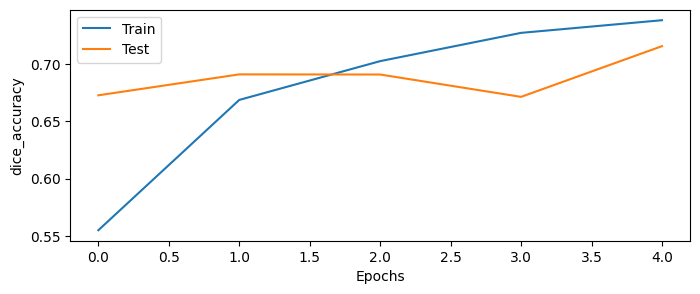

In [ ]:
def plot_graphs(history, metric):
    plt.figure(figsize=(8, 3))
    plt.plot(history.history[metric])
    plt.plot(history.history['val_'+metric], '')
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend(["Train", "Test"])
    plt.show()
plot_graphs(history, 'dice_accuracy')

In [ ]:
predictions = deconv_model.predict(val_dataset)



60/60 ━━━━━━━━━━━━━━━━━━━━ 360s 6s/step


In [ ]:
np.save("predictions.npy", predictions)

In [ ]:
plt.imsave("sample_output.png", predictions[0, :, :, 0], cmap="gray")

In [ ]:
convert_tf_data_to_np(train_dataset);

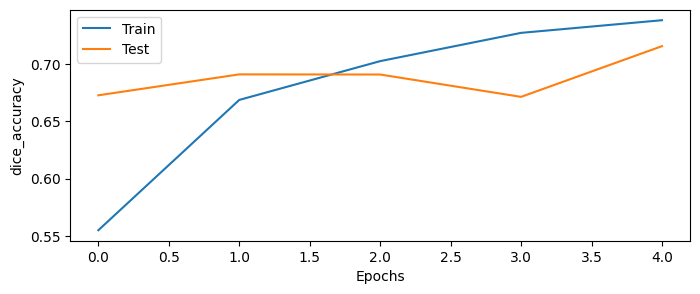

30/30 ━━━━━━━━━━━━━━━━━━━━ 352s 12s/step
0.7153310067631602


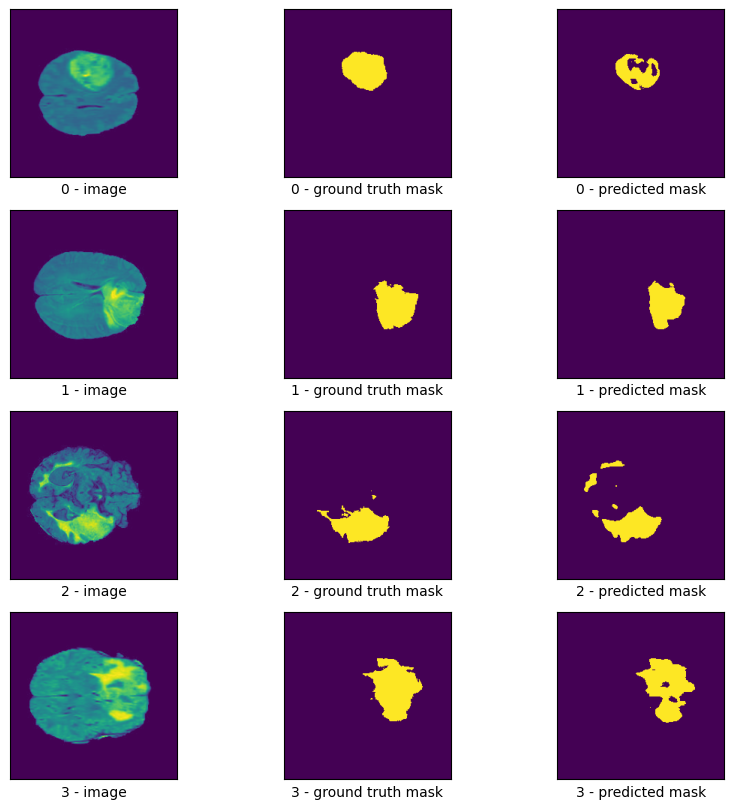

In [ ]:
plot_graphs(history, 'dice_accuracy')
X_val, Y_val = convert_tf_data_to_np(val_dataset)
Y_val = np.argmax(Y_val, axis=-1)
Y1_pred = deconv_model.predict(X_val)
Y1_pred = np.argmax(Y1_pred, axis=-1)
mean_DSC = evaluate_DSC_in_data(Y_val, Y1_pred)
print(mean_DSC)
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.subplot(4, 3, i*3+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_val[i, :, :, :])
    plt.xlabel(str(int(i)) + ' - image')
    plt.subplot(4, 3, i*3+2)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(Y_val[i, :, :])
    plt.xlabel(str(int(i)) + ' - ground truth mask')
    plt.subplot(4, 3, i*3+3)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(Y1_pred[i, :, :])
    plt.xlabel(str(int(i)) + ' - predicted mask')
plt.show()

In [ ]:
np.save('/content/drive/MyDrive/predictions.npy', Y1_pred)


In [ ]:
deconv_model.save('/content/drive/MyDrive/Capstone Project - Brain Tumor Segmentation/baseline_model.keras')

In [ ]:
with open('/content/drive/MyDrive/training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)